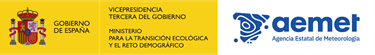

# Ecosistema Earthkit

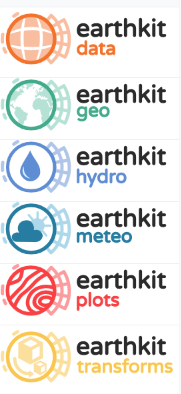

(basado en https://earthkit.readthedocs.io/en/latest/tutorials/meteo_computations.html)

Para abrir el notebook en Colab o Binder pulsa el botón respectivo:

<a target="_blank" href="https://colab.research.google.com/github/pibm-curso/python_para_meteorologia/blob/main/librerias_cientificas/5_earthkit.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/pibm-curso/python_para_meteorologia/HEAD?urlpath=%2Fdoc%2Ftree%2Flibrerias_cientificas%2F5_earthkit.ipynb)

Se instala earthkit:

In [ ]:
pip install -q earthkit

Descarga de ficheros de ejemplo:

In [ ]:
!test -f era5_karl2010_sfc_inst.nc || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/era5_karl2010_sfc_inst.nc -O era5_karl2010_sfc_inst.nc

### Introducción

earthkit es un ecosistema de código abierto desarrollado en Python y liderado por el Centro Europeo de Previsiones Meteorológicas a Plazo Medio (ECMWF). Su objetivo principal es simplificar y acelerar los flujos de trabajo en las ciencias de la Tierra, la meteorología y el clima.

Funciona de manera modular a través de varias librerías interoperables:  
- earthkit-data: La interfaz unificada y agnóstica para el acceso y lectura de datos geoespaciales.  
- earthkit-geo: Dedicado a cálculos geoespaciales e interpolaciones eficientes entre mallas espaciales.  
- earthkit-hydro: Diseñado específicamente para operaciones hidrológicas y análisis de redes de ríos.  
- earthkit-meteo: El módulo encargado de los cálculos meteorológicos y postprocesado científico.  
- earthkit-plots: Las herramientas de visualización automatizada basadas en metadatos para generar mapas listos para publicación.  
- earthkit-transforms: La librería especializada en la agregación, análisis estadístico y transformaciones temporales o multidimensionales de los datos.  

Se integra de forma nativa con herramientas del ecosistema de datos de Python como NumPy, Pandas, Xarray, PyTorch y CuPy para aceleración por GPU.

En cierto sentido es una capa puesta encima de todas estas librerías de python que nos permite manejar datos meteorológicos de forma unificada. Vamos a ver un ejemplo simple.

### Descarga de datos y cálculo de la velocidad del viento

In [ ]:
import earthkit.data as ekd
import earthkit.plots as ekp
from earthkit.meteo.wind.fieldlist import speed

earthkit-data permite descargar datos del Climate Data Store de la misma forma que si usamos la librería cdsapi (de hecho la sintaxis es igual): 

In [ ]:
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "2m_temperature",
        "land_sea_mask"
    ],
    "year": ["2010"],
    "month": ["09"],
    "day": [
        "14", "15", "16",
        "17", "18"
    ],
    "time": [
        "00:00", "03:00", "06:00",
        "09:00", "12:00", "15:00",
        "18:00", "21:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [30, -105, 3, -65],
}

ds = ekd.from_source("cds", dataset, request)

Y aquí un ejemplo de visualización del huracán Karl, muy parecido a lo que vimos con xarray y cartopy:

In [ ]:
ds = ekd.from_source("file", "era5_karl2010_sfc_inst.nc").to_fieldlist()

In [ ]:
# select the u and v fields. We assume here they
# are valid for the same set of levels
u = ds.sel({"parameter.variable": "u10"})
v = ds.sel({"parameter.variable": "v10"})

ds_ws = speed(u, v)

In [ ]:
ds_ws.ls()

In [ ]:
ds_ws.to_target("file", "_ws_res.nc")

# read back saved data and check first 2 fields
ds_ws = ekd.from_source("file", "_ws_res.nc").to_fieldlist()
ds_ws.head(2)

In [ ]:
i=10
chart = ekp.Map(domain=[-95,-75,10,24], size=(6, 6))
chart.contourf(
    ds_ws[i],
    units="m s-1",
    colors="Greens",
    alpha=1,
)
chart.quiver(u=u[i], v=v[i])
chart.coastlines()
chart.gridlines()
chart.legend()
chart.title(("{time:%Y-%m-%d %H} UTC (+{lead_time}h) {level} hPa"))

chart.show()